# Problem Statement

- The quality of wine depends on several physicochemical properties such as acidity, sugar content, alcohol level, pH, and sulphates. Manually evaluating wine quality is time-consuming, expensive, and subjective. The goal of this project is to build a machine learning model that predicts the quality of wine based on its chemical properties, enabling faster, more consistent, and data-driven quality assessment.

# Objectives
- Collect and preprocess the wine quality dataset.
Perform Exploratory Data Analysis (EDA) to understand the data and identify patterns.
Handle missing values, duplicates, and outliers (if any).
Select relevant features that influence wine quality.
Train multiple machine learning classification models.
Compare model performance using evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
Identify the best-performing model for predicting wine quality.
Develop a reliable model that can accurately predict wine quality from its physicochemical attributes.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\lahar\Downloads\winequality.csv")

In [4]:
# display dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red


In [5]:
# last rows
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,0,white


In [6]:
#shape
df.shape

(6497, 14)

In [7]:
#columns names
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'good', 'color'],
      dtype='object')

In [8]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  good                  6497 non-null   int64  
 13  color                 6497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB


In [9]:
# check missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
good                    0
color                   0
dtype: int64

In [10]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(1177)

In [11]:
df = df.drop_duplicates()

In [12]:
#Statistical Summary
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677,0.189662
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772,0.392070
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000,0.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [13]:
#Check Data Types
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
good                      int64
color                    object
dtype: object

In [14]:
#Unique Values
df.nunique()

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               224
free sulfur dioxide     135
total sulfur dioxide    276
density                 998
pH                      108
sulphates               111
alcohol                 112
quality                   7
good                      2
color                     2
dtype: int64

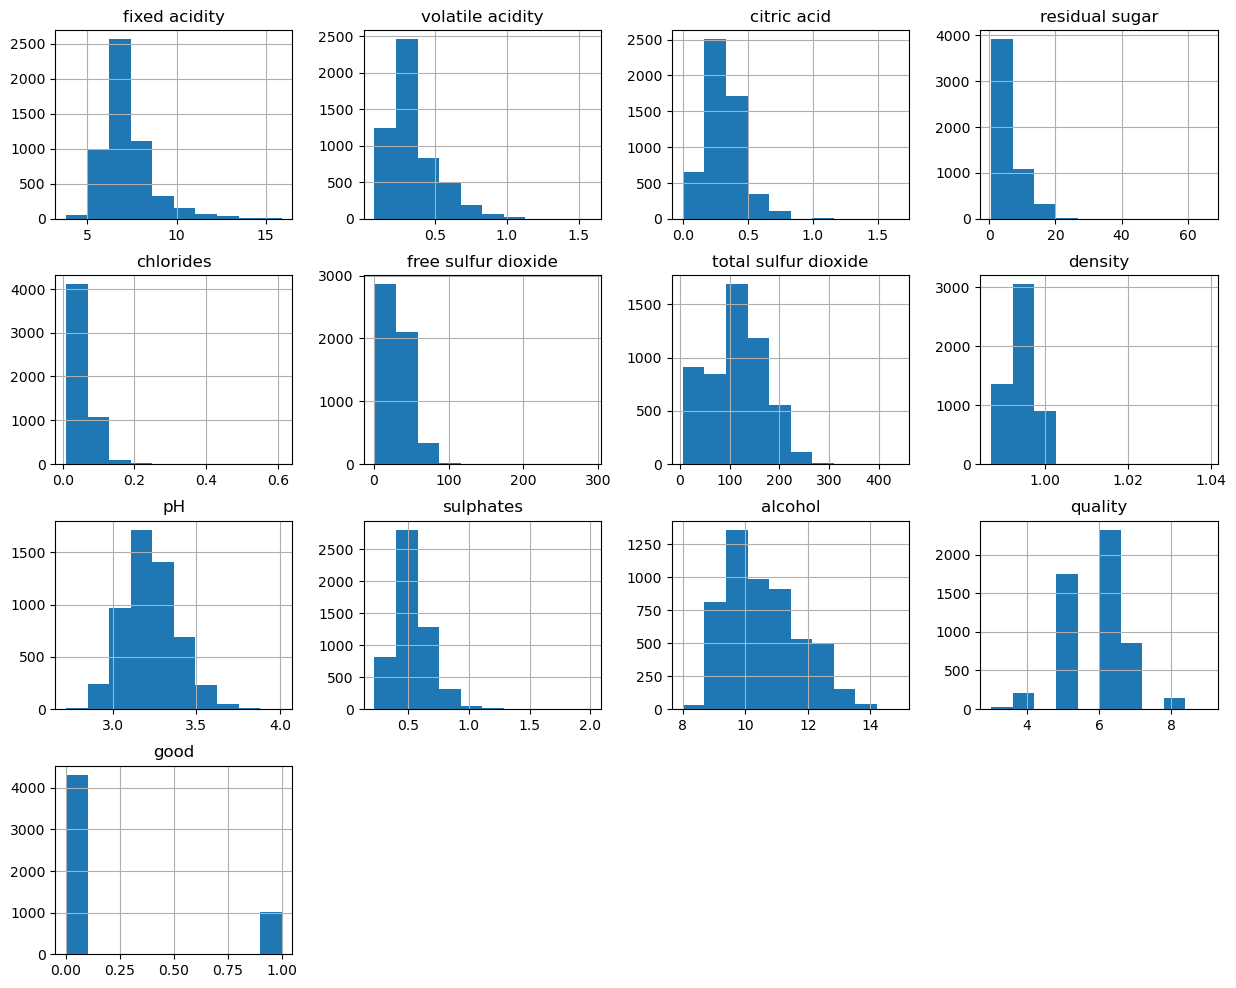

In [15]:
#Distribution of Every Column
df.hist(figsize=(15,12))

plt.show()

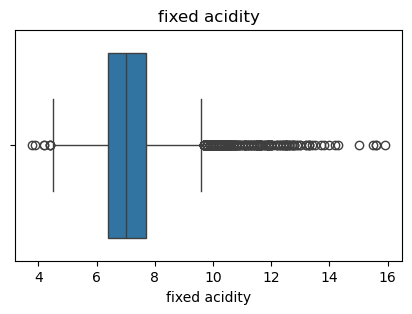

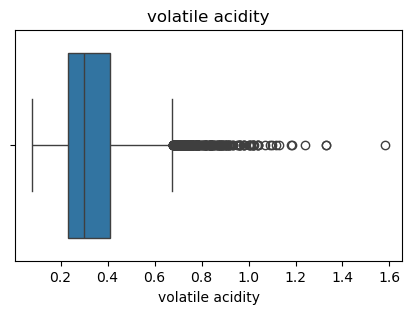

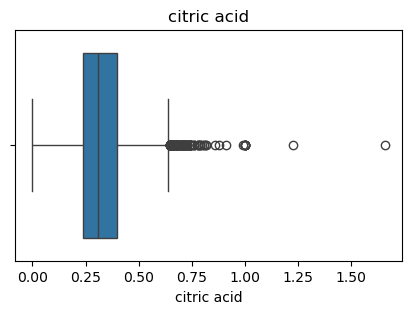

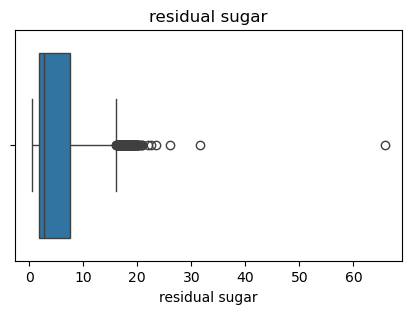

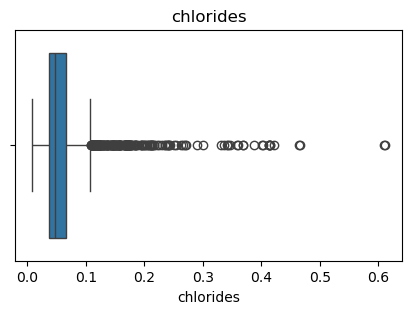

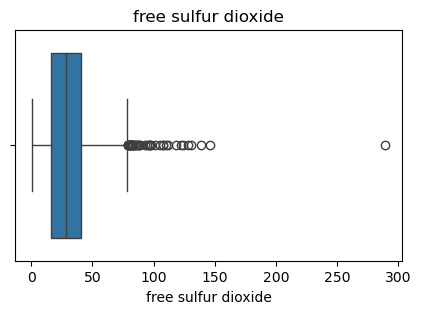

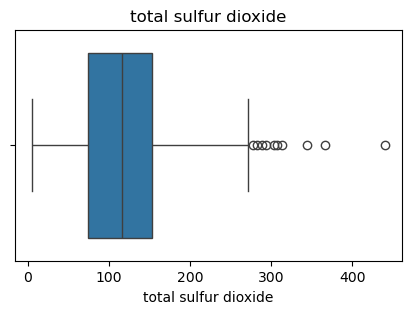

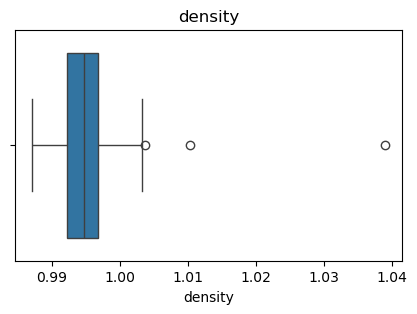

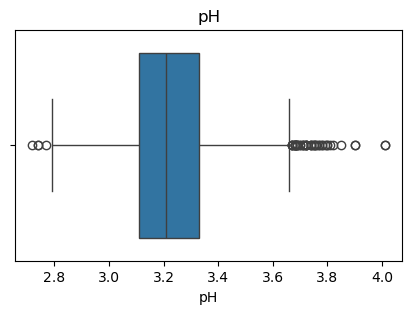

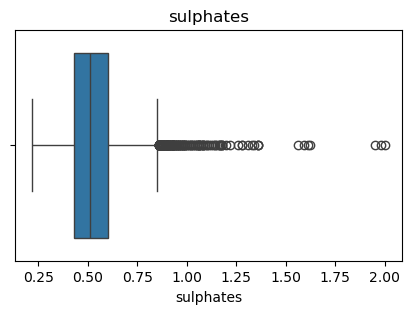

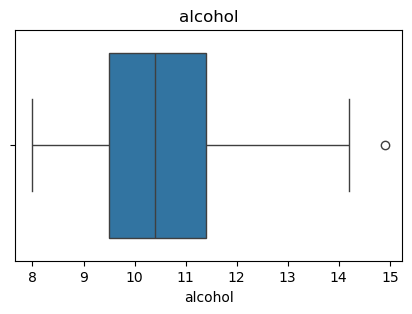

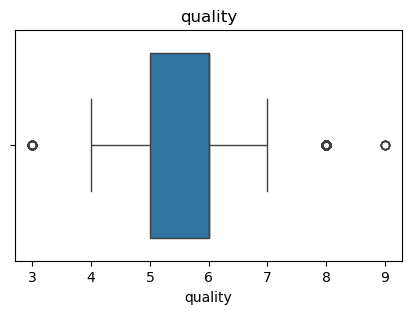

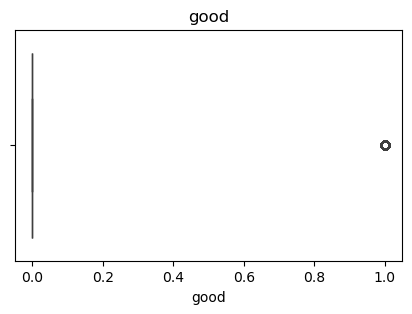

In [16]:
# Boxplots
for col in df.select_dtypes(include=np.number):

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

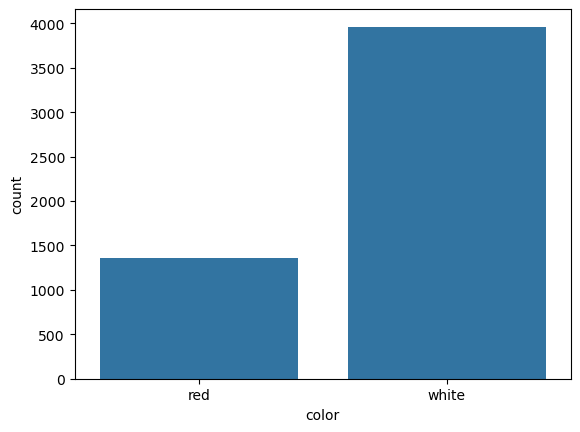

In [17]:
#Countplot of Color
sns.countplot(x="color",data=df)

plt.show()

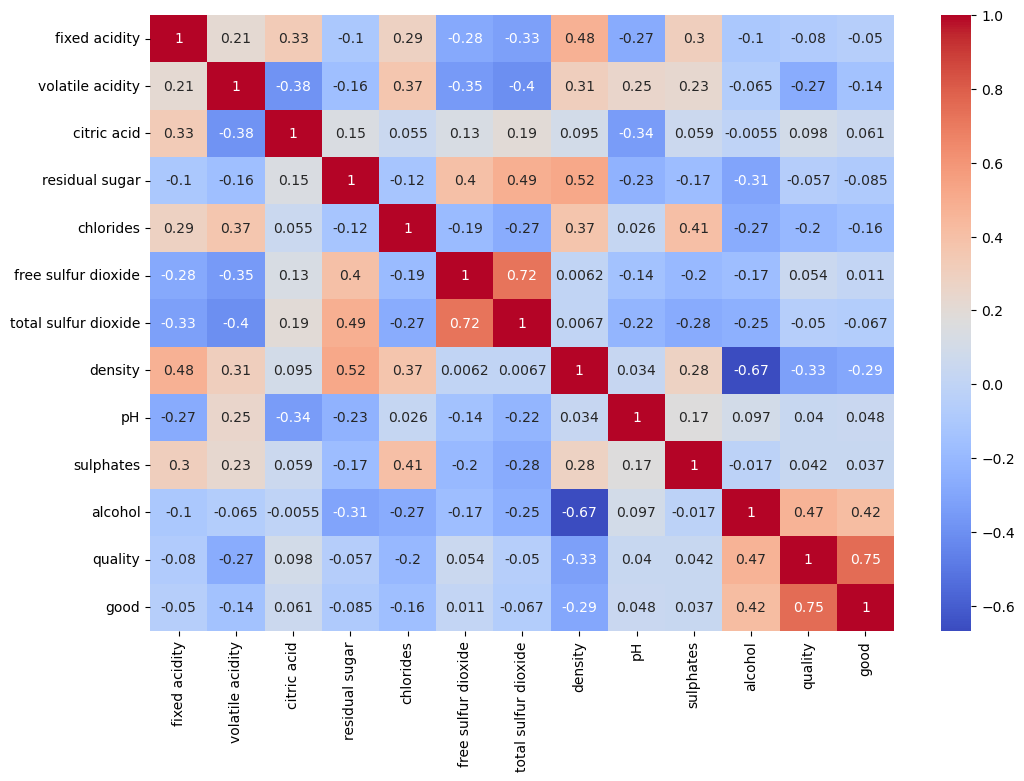

In [18]:
#Correlation Matrix of heat map
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [19]:
#Correlation with Target
corr=df.corr(numeric_only=True)

corr["quality"].sort_values(ascending=False)

quality                 1.000000
good                    0.748442
alcohol                 0.469422
citric acid             0.097954
free sulfur dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total sulfur dioxide   -0.050296
residual sugar         -0.056830
fixed acidity          -0.080092
chlorides              -0.202137
volatile acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64

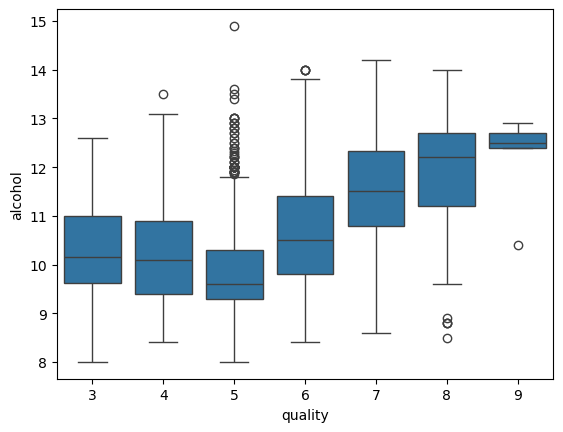

In [20]:
#Alcohol vs Quality
sns.boxplot(x="quality",
            y="alcohol",
            data=df)

plt.show()

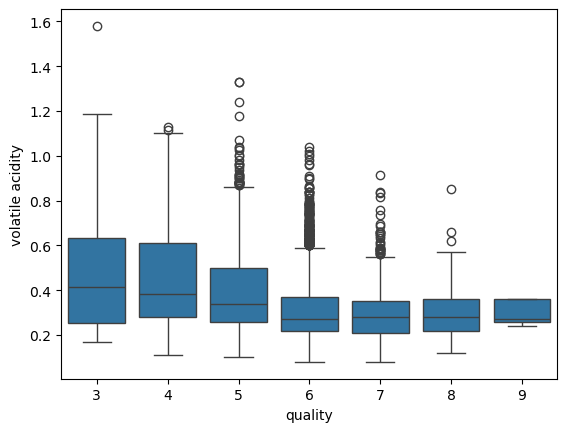

In [21]:
#Volatile Acidity vs Quality
sns.boxplot(x="quality",
            y="volatile acidity",
            data=df)

plt.show()

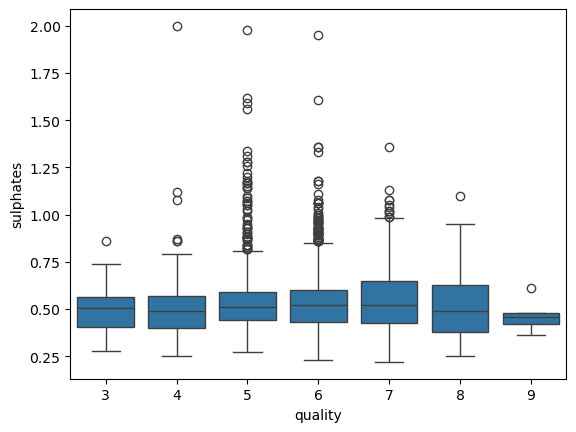

In [22]:
#Sulphates vs Quality
sns.boxplot(x="quality",
            y="sulphates",
            data=df)

plt.show()

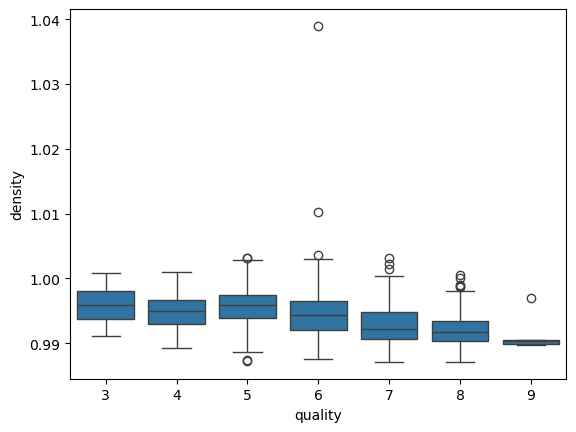

In [23]:
#Density vs Quality
sns.boxplot(x="quality",
            y="density",
            data=df)

plt.show()

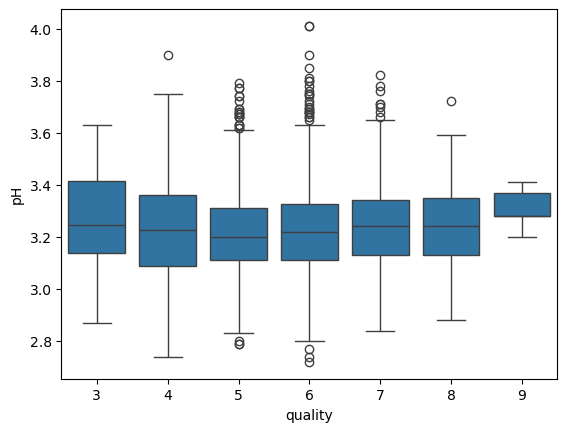

In [24]:
#pH vs Quality
sns.boxplot(x="quality",
            y="pH",
            data=df)

plt.show()

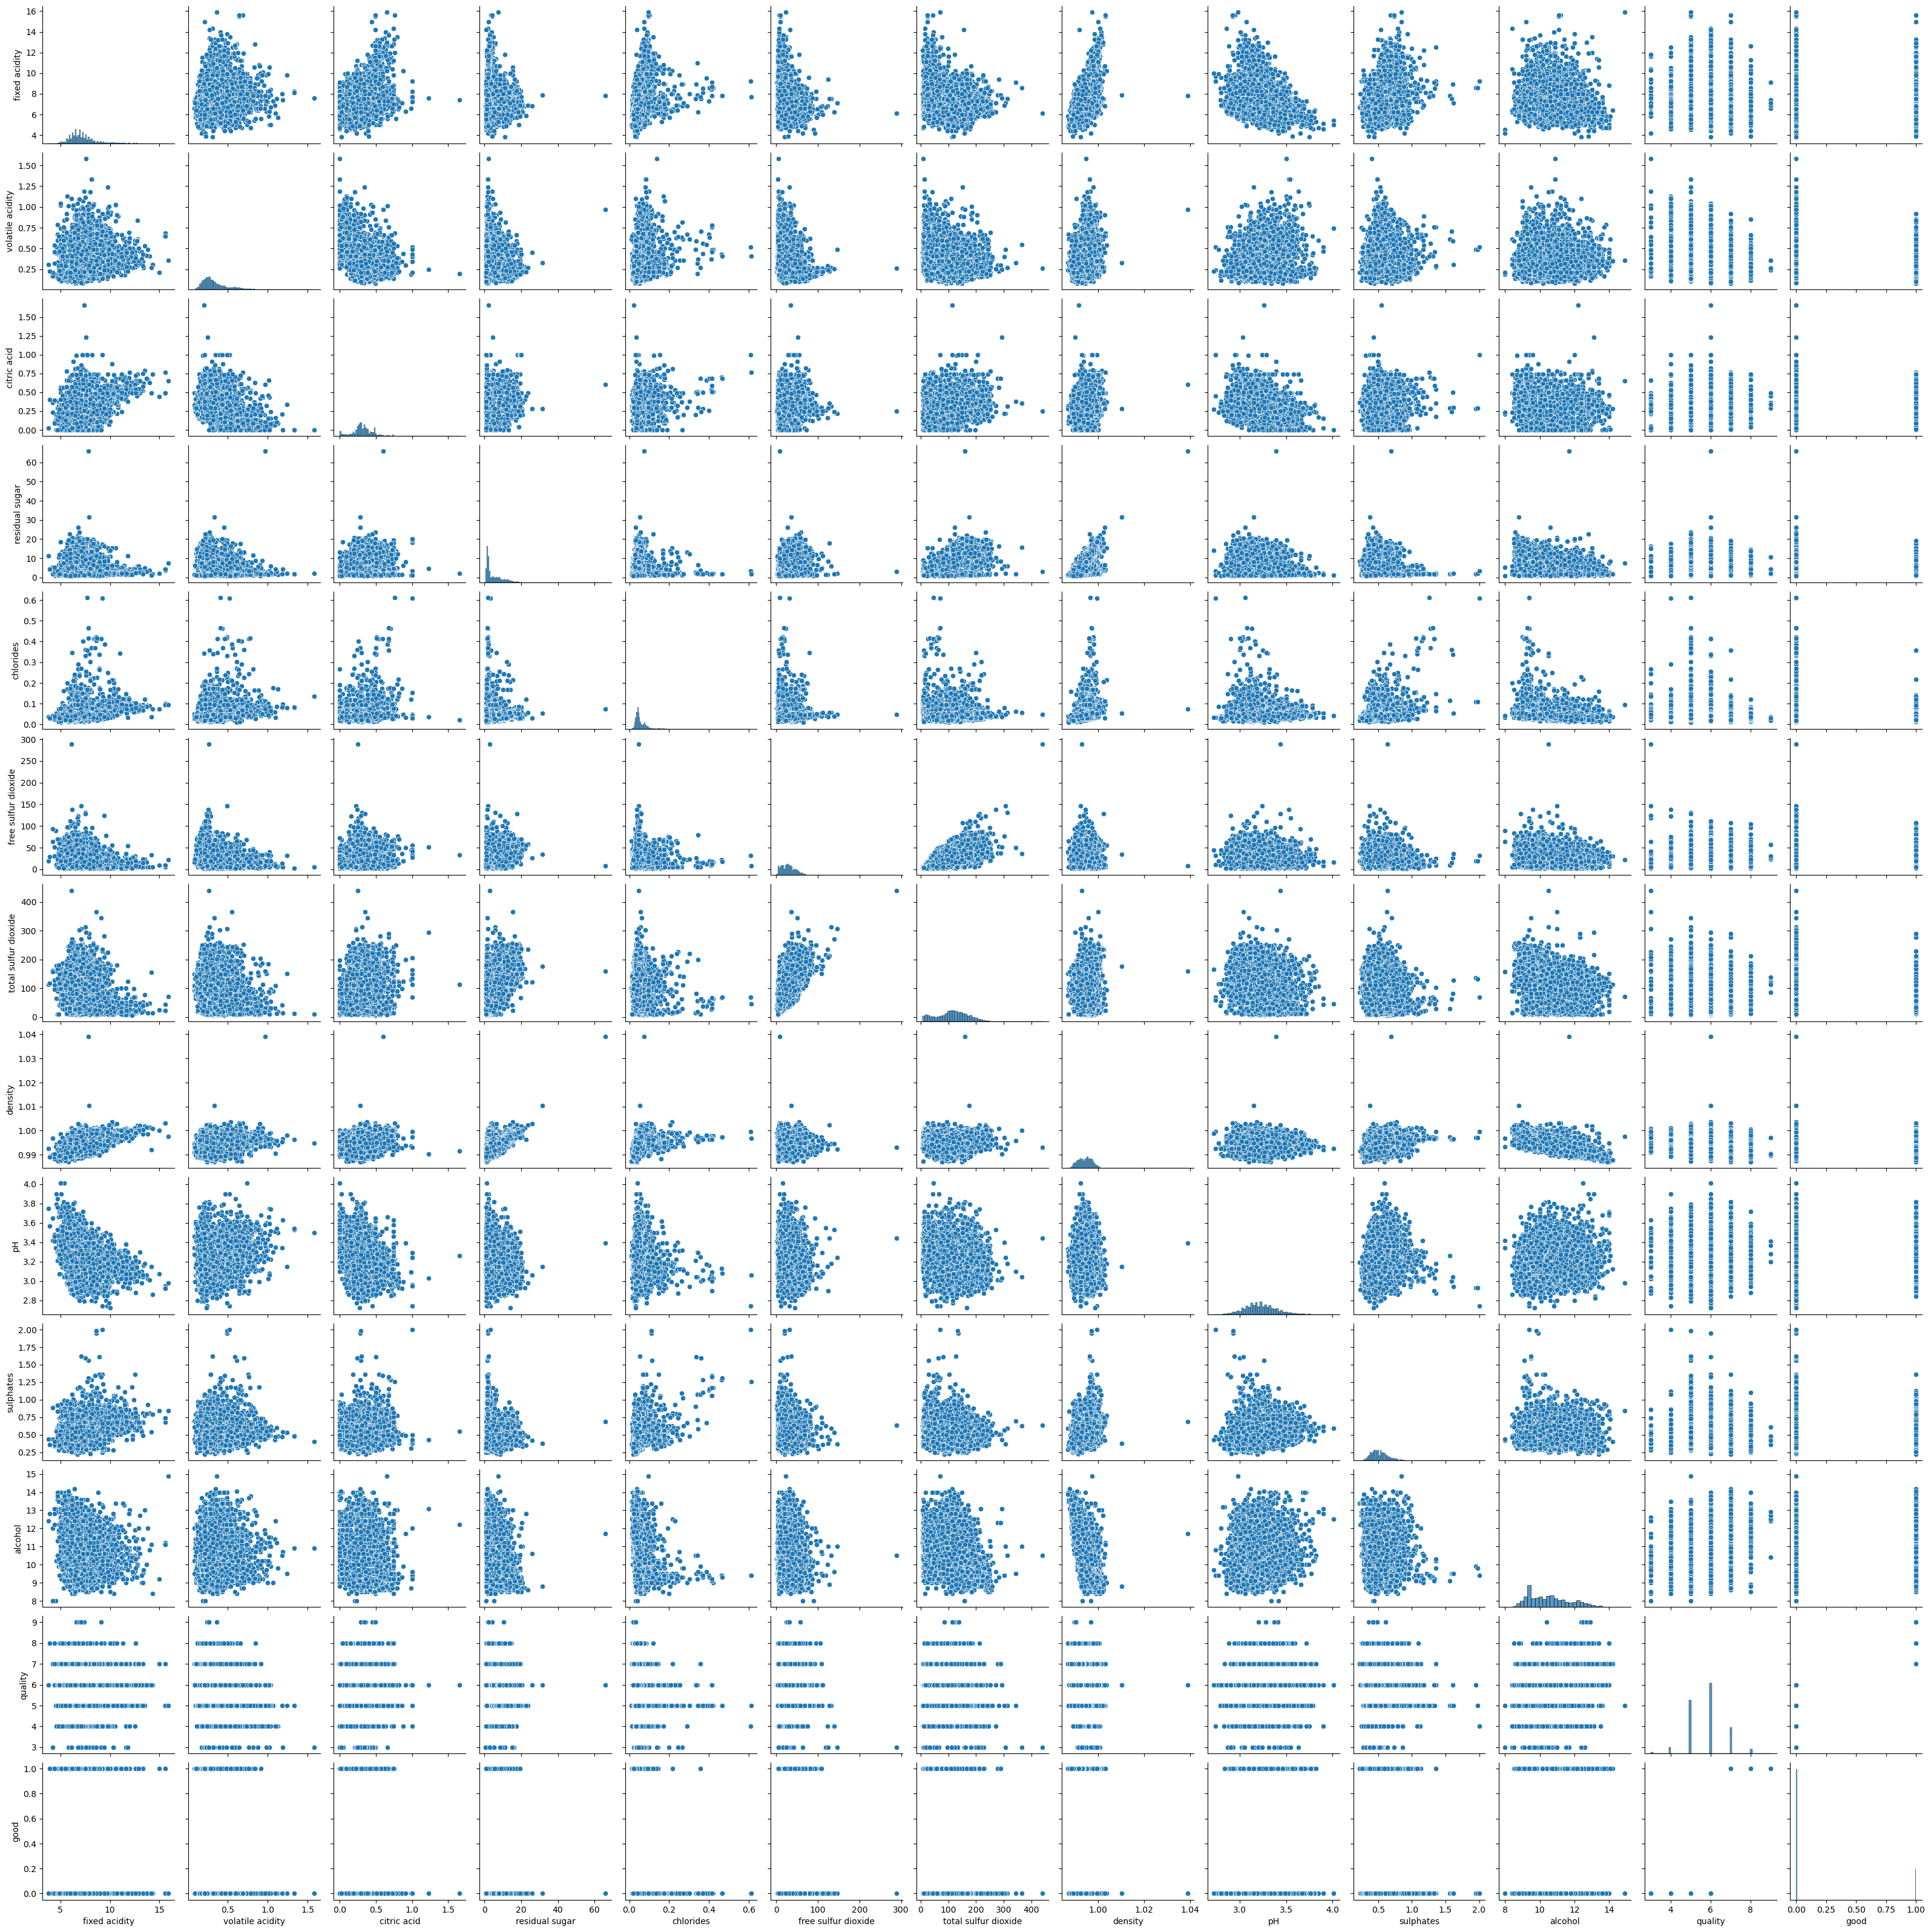

In [26]:
#Pairplot
sns.pairplot(df)
plt.show()

## Business Insights

1.Most wines in the dataset have a quality score between 5 and 7, indicating that average-quality wines are more common than very low- or very high-quality wines.

2.Alcohol content has a positive relationship with wine quality. Wines with higher alcohol levels tend to receive higher quality ratings.

3.Volatile acidity has a negative impact on wine quality. Higher volatile acidity is generally associated with lower-quality wines.

4.Sulphates show a positive correlation with quality. Wines with moderate sulphate levels are more likely to have better quality scores.

5.Residual sugar and density have a relatively weak relationship with wine quality, suggesting they are less influential than alcohol or acidity.

6.The dataset contains both red and white wines, and their physicochemical properties differ, which may affect quality prediction.

7.Some features contain outliers, but these may represent real variations in wine production rather than errors.

8.The correlation analysis shows that alcohol, volatile acidity, sulphates, and citric acid are among the most important variables for predicting wine quality.

## Business Recommendations

1.Focus on maintaining optimal alcohol levels, as alcohol content has a strong positive influence on wine quality.

2.Reduce volatile acidity during the production process to improve the overall quality of wine.

3.Regularly monitor sulphate levels to ensure product stability while maintaining good taste and quality.

4.Use data-driven quality prediction models to identify potential quality issues before the wine reaches customers.

5.Continuously monitor important chemical properties such as acidity, alcohol, sulphates, and citric acid during wine production.

6.Use predictive analytics to improve quality consistency, reduce production costs, and strengthen customer satisfaction.

7.Develop separate quality control strategies for red and white wines, as their characteristics differ.

8.Continuously analyze production data to optimize the winemaking process and improve overall product quality.

# conclusion 
- Based on the exploratory data analysis, alcohol content, volatile acidity, sulphates, and citric acid are the most influential factors affecting wine quality. By monitoring these key variables and applying machine learning models, wineries can improve product quality, ensure consistency, and make better business decisions.